# Credit Default Risk — Prediction Framework

**Dataset:** Give Me Some Credit (Kaggle) — 150,000 U.S. loan applicants  
**Role:** Junior Analyst, Retail Lending Risk Team  
**Objective:** Build a credit default prediction framework to support credit committee approval decisions.

---

## Section 1 — Data Understanding & Quality Assessment

**Business question:** What does our applicant pool look like, and how clean is the data?

Before building any model, we need to understand what we're working with. A model trained on dirty data will produce unreliable scores — and unreliable scores lead to bad lending decisions. This section examines:
- Who is in the dataset and what we're trying to predict
- Where data is missing and what that means for the lender
- Which values are impossible or implausible, and how we'll treat them

The goal isn't just to clean data. It's to make decisions a credit analyst could defend in a risk committee.`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/cs-training.csv', index_col=0)

print(f"Rows        : {df.shape[0]:,}")
print(f"Columns     : {df.shape[1]}")

print('\n|--------Column----------------|---DataType-----|')
print(df.dtypes)

Rows        : 150,000
Columns     : 11

|--------Column----------------|---DataType-----|
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


In [3]:
counts = df['SeriousDlqin2yrs'].value_counts()
default_rate = df['SeriousDlqin2yrs'].mean()

print(f"Non-defaulters (0) : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Defaulters     (1) : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
print(f"Base default rate  : {default_rate:.2%}")
print(f"Imbalance ratio    : {counts[0]/counts[1]:.0f}:1")

Non-defaulters (0) : 139,974  (93.3%)
Defaulters     (1) : 10,026  (6.7%)
Base default rate  : 6.68%
Imbalance ratio    : 14:1


### Why class imbalance matters more than accuracy

At a **14:1 ratio**, a model that predicts *nobody defaults* achieves ~93% accuracy — and catches **zero defaulters**.

This is the fundamental problem with using accuracy in credit risk. What matters to the lender is not how often the model is right overall, but whether it can correctly identify the minority of applicants who will default. A missed defaulter (false negative) costs the lender the full loan principal. A wrongly rejected borrower (false positive) costs only the foregone interest.

This is why credit risk practitioners use **AUC-ROC, KS Statistic, and Gini Coefficient** — all of which measure the model's ability to *rank* borrowers by risk, not just classify them correctly.

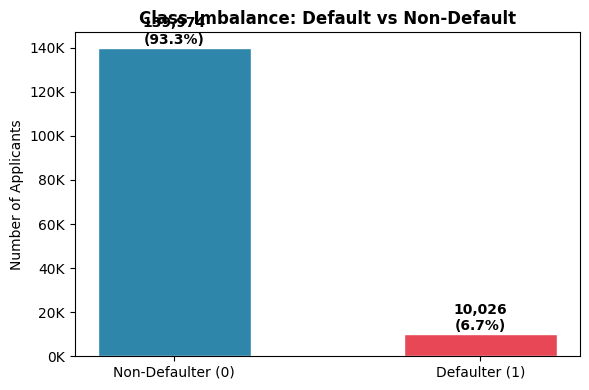

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    ['Non-Defaulter (0)', 'Defaulter (1)'],
    [counts[0], counts[1]],
    color=['#2E86AB', '#E84855'],
    width=0.5,
    edgecolor='white'
)

for bar, val in zip(bars, [counts[0], counts[1]]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{val:,}\n({val/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Class Imbalance: Default vs Non-Default', fontweight='bold')
ax.set_ylabel('Number of Applicants')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('../outputs/s1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Missing Values 

missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %':     (df.isnull().mean() * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing.to_string())

                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62


### Missing data treatment — what the credit analyst cares about

**MonthlyIncome (~20% missing)**  
This is a large gap. Applicants may be self-employed, in the informal sector, or simply declined to disclose income. We cannot drop these rows — that would remove 1 in 5 applicants from our training data, which is unacceptable.

Treatment: Impute using **median income grouped by age band**. We use median (not mean) because income is right-skewed — a few high earners pull the mean up artificially.

Crucially, we also create a binary flag: `income_missing = 1`. This flag stays in the model. In credit underwriting, the *absence* of income data is itself a signal — applicants who don't disclose income may carry higher risk. We want the model to learn that.

**NumberOfDependents (~2.6% missing)**  
Small gap, straightforward. Impute with global median. No meaningful signal in whether this field was left blank.

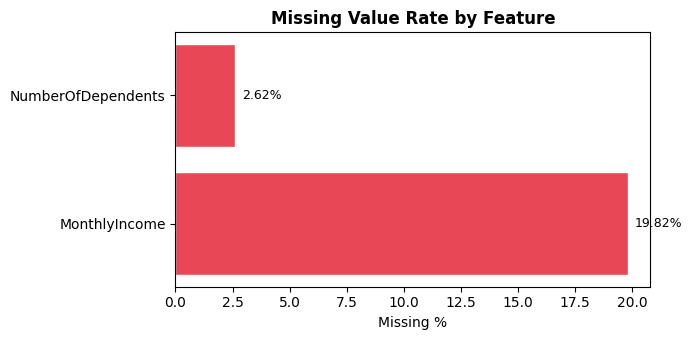

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))

ax.barh(missing.index, missing['Missing %'], color='#E84855', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Value Rate by Feature', fontweight='bold')

for i, val in enumerate(missing['Missing %']):
    ax.text(val + 0.3, i, f'{val}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/s1_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### Outlier analysis — sanity-checking the numbers

Raw data from loan applications is notoriously messy. Self-reported figures, legacy data entry errors, and system sentinel codes all create values that are technically present but analytically useless. Before any modelling, we need to identify and treat these.

In [7]:
outlier_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'age'
]

stats = df[outlier_features].describe(percentiles=[.01, .25, .5, .75, .95, .99])
print(stats.T[['min', '1%', '50%', '95%', '99%', 'max']].to_string())

                                      min    1%          50%      95%           99%        max
RevolvingUtilizationOfUnsecuredLines  0.0   0.0     0.154181      1.0      1.092956    50708.0
DebtRatio                             0.0   0.0     0.366508   2449.0   4979.040000   329664.0
MonthlyIncome                         0.0   0.0  5400.000000  14587.6  25000.000000  3008750.0
NumberOfTime30-59DaysPastDueNotWorse  0.0   0.0     0.000000      2.0      4.000000       98.0
NumberOfTimes90DaysLate               0.0   0.0     0.000000      1.0      3.000000       98.0
age                                   0.0  24.0    52.000000     78.0     87.000000      109.0


### What the outlier table tells us

| Feature | Issue | Treatment |
|---------|-------|-----------|
| `RevolvingUtilization` | Values above 1.0 are mathematically impossible (>100% utilisation). Some reach 50,000+. | Cap at 1.0 — standard bureau treatment |
| `DebtRatio` | Values in the thousands indicate data entry or reporting errors | Cap at 99th percentile |
| `MonthlyIncome` | Extreme right skew — some entries exceed ₹30L+/month | Cap at 99th percentile before imputation |
| Delinquency columns | Values of 96 and 98 are **sentinel codes**, not actual delinquency counts | Treat as missing, then impute with 0 |
| `age` | Minimum value is 0 — clearly erroneous | Remove rows where age < 18 |

**Note on sentinel codes:** In older credit bureau data, 96 and 98 were used as placeholder codes when data wasn't collected. They are not real delinquency counts. Treating them as such would significantly inflate delinquency signals for those applicants.

In [8]:
df_clean = df.copy()

# Remove underage rows
df_clean = df_clean[df_clean['age'] >= 18].copy()

# Cap utilisation at 1.0
df_clean['RevolvingUtilizationOfUnsecuredLines'] = \
    df_clean['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1.0)

# Cap DebtRatio at p99
debt_99 = df_clean['DebtRatio'].quantile(0.99)
df_clean['DebtRatio'] = df_clean['DebtRatio'].clip(upper=debt_99)

# Cap MonthlyIncome at p99
income_99 = df_clean['MonthlyIncome'].quantile(0.99)
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].clip(upper=income_99)

# Replace sentinel codes with NaN
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]
for col in delinq_cols:
    df_clean[col] = df_clean[col].replace([98], np.nan)

print("Outlier treatment applied.")
print(f"  Utilisation capped at : 1.0")
print(f"  DebtRatio capped at   : {debt_99:,.1f}")
print(f"  MonthlyIncome capped  : {income_99:,.0f}")

Outlier treatment applied.
  Utilisation capped at : 1.0
  DebtRatio capped at   : 4,979.1
  MonthlyIncome capped  : 25,000


In [9]:
# Income missing flag (before imputation)
df_clean['income_missing'] = df_clean['MonthlyIncome'].isnull().astype(int)

# Impute income by age band median
df_clean['age_band'] = pd.cut(
    df_clean['age'],
    bins=[17, 30, 40, 50, 60, 120],
    labels=['18-30', '31-40', '41-50', '51-60', '60+']
)
income_medians = df_clean.groupby('age_band')['MonthlyIncome'].transform('median')
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(income_medians)
df_clean['MonthlyIncome'] = df_clean['MonthlyIncome'].fillna(df_clean['MonthlyIncome'].median())

# Impute dependents
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(
    df_clean['NumberOfDependents'].median()
)

# Impute delinquency sentinels with 0
for col in delinq_cols:
    df_clean[col] = df_clean[col].fillna(0)

# Drop helper column
df_clean.drop(columns=['age_band'], inplace=True)

print("Imputation complete.")
print(f"  income_missing flag: {df_clean['income_missing'].sum():,} applicants ({df_clean['income_missing'].mean():.1%})")

Imputation complete.
  income_missing flag: 29,731 applicants (19.8%)


---

## Section 1 Summary — Key Findings

| Item | Finding |
|------|---------|
| Total applicants | 150,000 |
| Base default rate | ~6.7% (14:1 class imbalance) |
| Rows removed | 1 (age = 0) |
| MonthlyIncome missing | ~20% → imputed by age band median, flag retained |
| NumberOfDependents missing | ~2.6% → imputed by global median |
| Outlier treatments | Utilisation capped at 1.0; DebtRatio and Income capped at p99 |
| Sentinel codes | 96/98 in delinquency columns treated as missing, imputed to 0 |
| New features created | `income_missing` (binary flag) |

**Key takeaway for the credit committee:**  
The data is usable, but not clean out of the box. Roughly 1 in 5 applicants have no declared income — that silence is retained as a model feature. The extreme class imbalance means we will not evaluate models on accuracy. AUC, KS, and Gini are our benchmarks throughout.

---

## Section 3 — Feature Engineering

**Business question:** How do we translate raw data into risk signals a model can learn from?

Raw variables are rarely in the best shape for a credit model. A delinquency count of 3 and a count of 0 are just numbers — but a binary flag that says *this person has ever been severely delinquent* is a much sharper risk signal. 

Here every feature created has a **credit rationale**. 

Five categories of features:
1. **Delinquency flags** — has this borrower ever missed payments, and how severely?
2. **Debt burden ratio** — is the borrower overextended relative to income?
3. **Utilisation risk flag** — is the borrower consistently maxing out revolving credit?
4. **Age risk flag** — is the borrower in a higher-risk age bracket?
5. **Log transformations** — stabilise skewed distributions for modelling

In [10]:
df = pd.read_csv('../data/credit_clean.csv')

base_rate = df['SeriousDlqin2yrs'].mean()
print(f"Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Base default rate: {base_rate:.2%}")
print(f"\nOriginal columns:\n{list(df.columns)}")

Loaded: 149,999 rows, 12 columns
Base default rate: 6.68%

Original columns:
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'income_missing']


### Feature 1 — Total Delinquency Burden

**Credit rationale:**  
The dataset has three separate delinquency columns: 30–59 day, 60–89 day, and 90+ day past due counts. Each captures a different severity level.

A borrower might show zero 90-day delinquencies but have repeated 30–59 day misses — which still signals payment unreliability. By summing all three, we create a single variable that captures the **total volume of missed payments** across severity levels.

This is a standard aggregation in credit scorecard development — the total delinquency burden is often more predictive than any individual delinquency column alone.

In [11]:
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

df['total_delinquencies'] = df[delinq_cols].sum(axis=1)

# Sense check
delinq_summary = df.groupby(
    df['total_delinquencies'].clip(upper=5)
).agg(
    count   = ('SeriousDlqin2yrs', 'count'),
    default_rate = ('SeriousDlqin2yrs', 'mean')
).reset_index()

delinq_summary.columns = ['Total Delinquencies', 'Count', 'Default Rate']
delinq_summary['Default Rate'] = delinq_summary['Default Rate'].map('{:.2%}'.format)

print("SENSE CHECK — Total Delinquency Burden vs Default Rate")
print("=" * 52)
print(delinq_summary.to_string(index=False))

SENSE CHECK — Total Delinquency Burden vs Default Rate
 Total Delinquencies  Count Default Rate
                 0.0 119901        2.84%
                 1.0  17242       12.21%
                 2.0   5942       24.08%
                 3.0   2884       34.95%
                 4.0   1595       42.63%
                 5.0   2435       57.25%


### Feature 2 — Ever Seriously Delinquent (Binary Flag)

**Credit rationale:**  
From the EDA, we saw that even a *single* prior 90-day delinquency significantly raises default risk. A binary flag captures this cleanly: has this borrower ever crossed the threshold into serious delinquency?

Binary flags are useful in models because they create a hard separation between two groups. They are also easy to explain to a credit committee: *yes or no, has this person previously failed to repay on time at a serious level?*

We define "seriously delinquent" as 1+ instances of 60-day or 90-day past due. The 30–59 day threshold is retained separately as a softer signal.

In [12]:
# Ever seriously delinquent: 60+ days at least once
df['ever_seriously_delinquent'] = (
    (df['NumberOfTime60-89DaysPastDueNotWorse'] > 0) |
    (df['NumberOfTimes90DaysLate'] > 0)
).astype(int)

# Ever 90+ day delinquent specifically
df['ever_90day_delinquent'] = (
    df['NumberOfTimes90DaysLate'] > 0
).astype(int)

# Sense check
for col, label in [
    ('ever_seriously_delinquent', 'Ever 60+ days late'),
    ('ever_90day_delinquent',     'Ever 90+ days late')
]:
    dr_yes = df[df[col] == 1]['SeriousDlqin2yrs'].mean()
    dr_no  = df[df[col] == 0]['SeriousDlqin2yrs'].mean()
    n_yes  = df[col].sum()
    print(f"{label}")
    print(f"  Flag = 1: {n_yes:,} applicants | Default rate: {dr_yes:.2%}")
    print(f"  Flag = 0: {len(df) - n_yes:,} applicants | Default rate: {dr_no:.2%}")
    print()

Ever 60+ days late
  Flag = 1: 12,885 applicants | Default rate: 35.36%
  Flag = 0: 137,114 applicants | Default rate: 3.99%

Ever 90+ days late
  Flag = 1: 8,074 applicants | Default rate: 41.23%
  Flag = 0: 141,925 applicants | Default rate: 4.72%



### Feature 3 — Debt-to-Income Ratio (DTI)

**Credit rationale:**  
`DebtRatio` in the raw data is defined as monthly debt payments divided by monthly income. In principle, this already is a DTI — but after our capping at the 99th percentile, and given the noise in the raw data, we recalculate it explicitly.

More importantly, we **bin it into risk tiers**. A continuous DTI of 0.43 vs 0.47 is not meaningfully different. But the jump from below 36% (standard mortgage guideline threshold) to above 50% (high stress zone) is significant and has real credit meaning.

Industry thresholds used:
- Below 36%: Generally considered manageable
- 36–50%: Elevated — worth scrutiny
- Above 50%: High stress — significantly elevated risk

In [13]:
# DTI is already DebtRatio — create tiered version
df['dti_tier'] = pd.cut(
    df['DebtRatio'],
    bins=[-0.001, 0.36, 0.50, float('inf')],
    labels=['Low (<36%)', 'Elevated (36–50%)', 'High (>50%)']
)

# Sense check
dti_summary = df.groupby('dti_tier').agg(
    count        = ('SeriousDlqin2yrs', 'count'),
    default_rate = ('SeriousDlqin2yrs', 'mean')
).reset_index()

dti_summary.columns = ['DTI Tier', 'Count', 'Default Rate']
dti_summary['Default Rate'] = dti_summary['Default Rate'].map('{:.2%}'.format)

print("SENSE CHECK — DTI Risk Tier vs Default Rate")
print("=" * 44)
print(dti_summary.to_string(index=False))

SENSE CHECK — DTI Risk Tier vs Default Rate
         DTI Tier  Count Default Rate
       Low (<36%)  73861        5.83%
Elevated (36–50%)  19846        6.81%
      High (>50%)  56292        7.76%


### Feature 4 — High Utilisation Flag

**Credit rationale:**  
From the EDA, credit utilisation showed a clear monotonic relationship with default — the higher the utilisation, the higher the risk. The 80% threshold is widely used in credit scoring as the inflection point where risk rises sharply.

A binary flag at this threshold gives the model a clean signal: *is this borrower consistently running close to their credit limit?* Borrowers above 80% utilisation are often doing so because they have no buffer — they are dependent on revolving credit to meet day-to-day expenses.

In [14]:
df['high_utilisation'] = (
    df['RevolvingUtilizationOfUnsecuredLines'] > 0.80
).astype(int)

# Sense check
dr_high = df[df['high_utilisation'] == 1]['SeriousDlqin2yrs'].mean()
dr_low  = df[df['high_utilisation'] == 0]['SeriousDlqin2yrs'].mean()
n_high  = df['high_utilisation'].sum()

print("SENSE CHECK — High Utilisation Flag vs Default Rate")
print("=" * 50)
print(f"High utilisation (>80%): {n_high:,} applicants | Default rate: {dr_high:.2%}")
print(f"Normal utilisation:      {len(df) - n_high:,} applicants | Default rate: {dr_low:.2%}")
print(f"\nRisk uplift: {(dr_high / dr_low - 1):.0%} higher default rate for high-utilisation borrowers")

SENSE CHECK — High Utilisation Flag vs Default Rate
High utilisation (>80%): 25,132 applicants | Default rate: 21.08%
Normal utilisation:      124,867 applicants | Default rate: 3.79%

Risk uplift: 457% higher default rate for high-utilisation borrowers


### Feature 5 — Young Borrower Flag

**Credit rationale:**  
The EDA showed that borrowers under 35 have above-average default rates — consistent with shorter credit histories, less stable employment, and less experience managing debt.

Rather than leaving age as a continuous variable (where the model has to learn the non-linear relationship itself), we encode the high-risk young borrower segment directly. This is a common practice in retail credit scorecards.

Note: in some regulatory environments, using age directly as a lending criterion is restricted. In a real deployment, this would be reviewed by compliance. For the purposes of this model, we include it as a predictive signal.

In [15]:
df['young_borrower'] = (df['age'] < 35).astype(int)

# Sense check
dr_young = df[df['young_borrower'] == 1]['SeriousDlqin2yrs'].mean()
dr_other = df[df['young_borrower'] == 0]['SeriousDlqin2yrs'].mean()
n_young  = df['young_borrower'].sum()

print("SENSE CHECK — Young Borrower Flag vs Default Rate")
print("=" * 50)
print(f"Age < 35: {n_young:,} applicants | Default rate: {dr_young:.2%}")
print(f"Age 35+:  {len(df) - n_young:,} applicants | Default rate: {dr_other:.2%}")

SENSE CHECK — Young Borrower Flag vs Default Rate
Age < 35: 19,239 applicants | Default rate: 11.18%
Age 35+:  130,760 applicants | Default rate: 6.02%


### Feature 6 — Log Transformations

**Credit rationale:**  
Several of our variables are heavily right-skewed: `MonthlyIncome`, `DebtRatio`, and `RevolvingUtilizationOfUnsecuredLines`. Linear models (Logistic Regression in particular) assume a roughly linear relationship between each feature and the log-odds of default.

When a variable is skewed, a ₹1,000 increase in income at the low end means something very different from the same increase at the high end. Log-transforming these variables compresses the scale and makes the relationship closer to linear — improving Logistic Regression performance without requiring the model to learn the non-linearity from scratch.

We add a small constant (1) before logging to handle zero values safely.

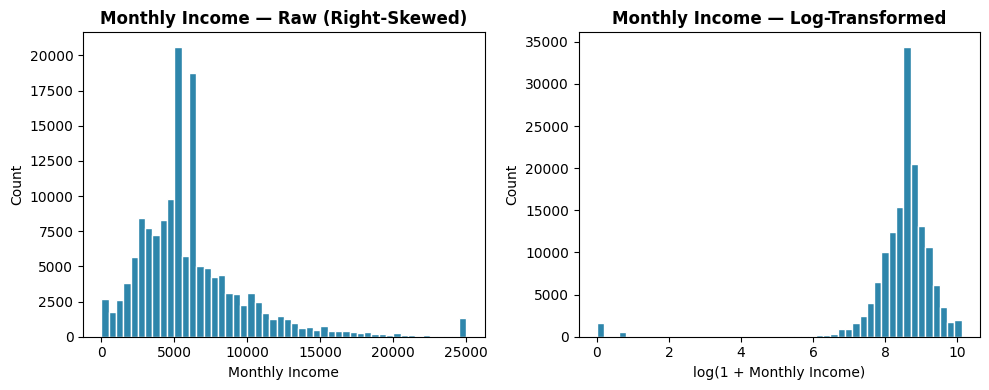

Log transformation applied to: MonthlyIncome, DebtRatio, RevolvingUtilization


In [16]:
df['log_income']      = np.log1p(df['MonthlyIncome'])
df['log_debt_ratio']  = np.log1p(df['DebtRatio'])
df['log_utilisation'] = np.log1p(df['RevolvingUtilizationOfUnsecuredLines'])

# Visual sense check — before vs after for income
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(df['MonthlyIncome'], bins=50, color='#2E86AB', edgecolor='white')
axes[0].set_title('Monthly Income — Raw (Right-Skewed)', fontweight='bold')
axes[0].set_xlabel('Monthly Income')
axes[0].set_ylabel('Count')

axes[1].hist(df['log_income'], bins=50, color='#2E86AB', edgecolor='white')
axes[1].set_title('Monthly Income — Log-Transformed', fontweight='bold')
axes[1].set_xlabel('log(1 + Monthly Income)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/s3_log_transform_income.png', dpi=150, bbox_inches='tight')
plt.show()

print("Log transformation applied to: MonthlyIncome, DebtRatio, RevolvingUtilization")

### Feature 7 — Revolving Lines per Dependent

**Credit rationale:**  
The number of open credit lines tells us how much revolving exposure a borrower carries. But the same number of credit lines means something different for a single person vs. someone supporting a family of four.

We divide open credit lines by (dependents + 1) to get a per-capita credit exposure metric. A borrower with 8 open lines and no dependents is in a very different position from one with 8 open lines and 4 children.

This kind of interaction feature is common in credit risk modelling — it captures a relationship between two raw variables that neither captures individually.

In [17]:
df['lines_per_dependent'] = (
    df['NumberOfOpenCreditLinesAndLoans'] / (df['NumberOfDependents'] + 1)
)

# Sense check using quartiles
quartiles = df['lines_per_dependent'].quantile([0.25, 0.5, 0.75])

q1_mask = df['lines_per_dependent'] <= quartiles[0.25]
q4_mask = df['lines_per_dependent'] >  quartiles[0.75]

dr_q1 = df[q1_mask]['SeriousDlqin2yrs'].mean()
dr_q4 = df[q4_mask]['SeriousDlqin2yrs'].mean()

print("SENSE CHECK — Credit Lines per Dependent (Q1 vs Q4)")
print("=" * 52)
print(f"Q1 (fewest lines per dependent): Default rate = {dr_q1:.2%}")
print(f"Q4 (most lines per dependent):   Default rate = {dr_q4:.2%}")
print(f"\nNote: direction of relationship matters — check if this feature is meaningful")

SENSE CHECK — Credit Lines per Dependent (Q1 vs Q4)
Q1 (fewest lines per dependent): Default rate = 8.96%
Q4 (most lines per dependent):   Default rate = 5.65%

Note: direction of relationship matters — check if this feature is meaningful


In [18]:
# All original + engineered columns
engineered = [
    'total_delinquencies',
    'ever_seriously_delinquent',
    'ever_90day_delinquent',
    'dti_tier',
    'high_utilisation',
    'young_borrower',
    'log_income',
    'log_debt_ratio',
    'log_utilisation',
    'lines_per_dependent'
]

print("ENGINEERED FEATURES SUMMARY")
print("=" * 60)
print(f"{'Feature':<30} {'Type':<15} {'Default Rate Diff'}")
print("-" * 60)

for col in engineered:
    if col == 'dti_tier':
        print(f"  {col:<28} categorical      (see sense check above)")
        continue
    if df[col].dtype in ['int64', 'float64']:
        corr = df[col].corr(df['SeriousDlqin2yrs'])
        print(f"  {col:<28} numeric          corr={corr:.3f}")

print()
print(f"Total columns before engineering : {df.shape[1] - len(engineered)}")
print(f"Total columns after engineering  : {df.shape[1]}")

# Save
df.to_csv('../data/credit_engineered.csv', index=False)
print("\nSaved: ../data/credit_engineered.csv")

ENGINEERED FEATURES SUMMARY
Feature                        Type            Default Rate Diff
------------------------------------------------------------
  total_delinquencies          numeric          corr=0.229
  ever_seriously_delinquent    numeric          corr=0.352
  ever_90day_delinquent        numeric          corr=0.330
  dti_tier                     categorical      (see sense check above)
  high_utilisation             numeric          corr=0.259
  young_borrower               numeric          corr=0.069
  log_income                   numeric          corr=-0.019
  log_debt_ratio               numeric          corr=-0.017
  log_utilisation              numeric          corr=0.271
  lines_per_dependent          numeric          corr=-0.045

Total columns before engineering : 12
Total columns after engineering  : 22

Saved: ../data/credit_engineered.csv


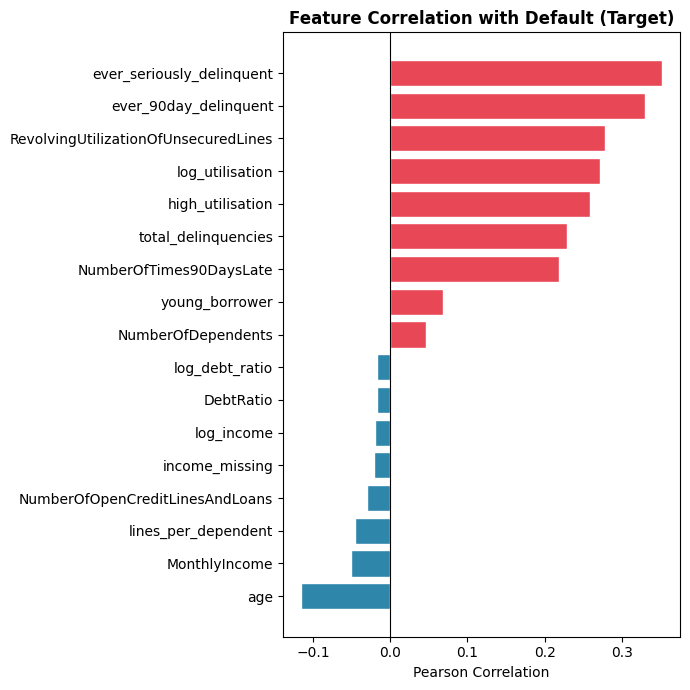


Top 5 positively correlated with default:
ever_seriously_delinquent               0.352
ever_90day_delinquent                   0.330
RevolvingUtilizationOfUnsecuredLines    0.278
log_utilisation                         0.271
high_utilisation                        0.259

Top 5 negatively correlated with default:
income_missing                     -0.021
NumberOfOpenCreditLinesAndLoans    -0.030
lines_per_dependent                -0.045
MonthlyIncome                      -0.051
age                                -0.115


In [19]:
# Show correlations of all features with the target
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTimes90DaysLate',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfDependents',
    'income_missing',
    'total_delinquencies',
    'ever_seriously_delinquent',
    'ever_90day_delinquent',
    'high_utilisation',
    'young_borrower',
    'log_income',
    'log_debt_ratio',
    'log_utilisation',
    'lines_per_dependent'
]

corr_with_target = (
    df[feature_cols + ['SeriousDlqin2yrs']]
    .corr()['SeriousDlqin2yrs']
    .drop('SeriousDlqin2yrs')
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(7, 7))

colors = ['#E84855' if v > 0 else '#2E86AB' for v in corr_with_target]

ax.barh(corr_with_target.index[::-1],
        corr_with_target.values[::-1],
        color=colors[::-1], edgecolor='white')

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Default (Target)', fontweight='bold')
ax.set_xlabel('Pearson Correlation')

plt.tight_layout()
plt.savefig('../outputs/s3_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 positively correlated with default:")
print(corr_with_target.head(5).map('{:.3f}'.format).to_string())
print("\nTop 5 negatively correlated with default:")
print(corr_with_target.tail(5).map('{:.3f}'.format).to_string())

---

## Section 3 Summary — Engineered Features

| Feature | Type | Credit Rationale |
|---------|------|-----------------|
| `total_delinquencies` | Numeric | Aggregates all missed payment history into one burden score |
| `ever_seriously_delinquent` | Binary | Hard signal: has this borrower ever crossed into serious delinquency? |
| `ever_90day_delinquent` | Binary | Strictest delinquency flag — 90+ days signals near-certain default |
| `dti_tier` | Categorical | Encodes debt burden into industry-standard risk bands |
| `high_utilisation` | Binary | Flags borrowers running >80% on revolving credit |
| `young_borrower` | Binary | Captures elevated risk for borrowers under 35 |
| `log_income` | Numeric | Stabilises right-skewed income distribution for Logistic Regression |
| `log_debt_ratio` | Numeric | Same treatment for debt ratio |
| `log_utilisation` | Numeric | Same treatment for utilisation |
| `lines_per_dependent` | Numeric | Per-capita credit exposure — interaction of credit lines and family size |

**Key takeaway for the credit committee:**

We have gone from 11 raw columns to a richer feature set that better captures the dimensions of credit risk. The most important new features are the delinquency flags — these translate messy count variables into clean binary signals that are easy to interpret and validate.

The log transformations primarily benefit the Logistic Regression model in Section 4. XGBoost and LightGBM handle skew natively and do not require them — but they do no harm either.

Check the correlation chart: features with the highest positive correlation are the ones most likely to carry weight in the model. Any feature with near-zero correlation with the target is a candidate for removal before modelling.

---

## Section 4 — Model Building & Evaluation

**Business question:** Which model best separates defaulters from non-defaulters, and how confident can we be in it?

Building a model is the easy part. Knowing whether to trust it — and being able to explain *why* it works — is what separates a portfolio project from a real risk deliverable.

We build three models in order of increasing complexity:
1. **Logistic Regression** — the industry baseline. Interpretable, auditable, and still used in production at many lenders. If a complex model cannot beat this, it is not worth the operational cost.
2. **XGBoost** — a gradient boosting model that captures non-linear relationships and interactions that Logistic Regression misses.
3. **LightGBM** — a faster, more memory-efficient gradient booster with native handling of class imbalance. Our challenger to XGBoost.

We evaluate all three models on the same three metrics:
- **AUC-ROC** — how well does the model rank borrowers from lowest to highest risk?
- **KS Statistic** — at what point does the model achieve maximum separation between defaulters and non-defaulters?
- **Gini Coefficient** — derived from AUC, standard in credit risk reporting (Gini = 2×AUC − 1)

We do not report accuracy. We never report accuracy.

In [20]:
from sklearn.linear_model    import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (roc_auc_score, roc_curve,
                                     confusion_matrix, classification_report)
from xgboost  import XGBClassifier
from lightgbm import LGBMClassifier

plt.rcParams.update({
    'figure.facecolor': '#F7F7F7',
    'axes.facecolor':   '#F7F7F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

In [21]:
df = pd.read_csv('../data/credit_engineered.csv')

# Drop categorical dti_tier — encode it numerically instead
dti_map = {'Low (<36%)': 0, 'Elevated (36–50%)': 1, 'High (>50%)': 2}
df['dti_tier_encoded'] = df['dti_tier'].map(dti_map).fillna(0).astype(int)

FEATURES = [
    # Original
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfDependents',
    # Engineered
    'income_missing',
    'total_delinquencies',
    'ever_seriously_delinquent',
    'ever_90day_delinquent',
    'high_utilisation',
    'young_borrower',
    'log_income',
    'log_debt_ratio',
    'log_utilisation',
    'lines_per_dependent',
    'dti_tier_encoded'
]

TARGET = 'SeriousDlqin2yrs'

X = df[FEATURES]
y = df[TARGET]

base_rate = y.mean()
imbalance_ratio = (y == 0).sum() / (y == 1).sum()

print(f"Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Base default rate    : {base_rate:.2%}")
print(f"Class imbalance ratio: {imbalance_ratio:.0f}:1")

Feature matrix: 149,999 rows × 21 features
Base default rate    : 6.68%
Class imbalance ratio: 14:1


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y       # preserve class ratio in both splits
)

print(f"Training set  : {X_train.shape[0]:,} rows | "
      f"Default rate: {y_train.mean():.2%}")
print(f"Test set      : {X_test.shape[0]:,} rows  | "
      f"Default rate: {y_test.mean():.2%}")
print()
print("Stratified split confirmed — default rate preserved in both sets.")

Training set  : 119,999 rows | Default rate: 6.68%
Test set      : 30,000 rows  | Default rate: 6.68%

Stratified split confirmed — default rate preserved in both sets.


### Why we stratify the split

With a 14:1 class imbalance, a random split risks putting very few defaulters in the test set — making evaluation unreliable. Stratified splitting ensures the default rate is consistent across train and test, so our metrics are comparable.

In [23]:
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Features scaled for Logistic Regression.")

Features scaled for Logistic Regression.


### How we measure model performance — plain English for the risk manager

**AUC-ROC (Area Under the ROC Curve)**  
Imagine lining up all 30,000 test applicants in order of the model's predicted default probability — lowest to highest. AUC tells you: if you pick one random defaulter and one random non-defaulter, what is the probability the model ranked the defaulter higher? AUC = 0.5 means the model is guessing. AUC = 1.0 means it is perfect. In credit risk, anything above 0.70 is usable; above 0.75 is good.

**KS Statistic (Kolmogorov-Smirnov)**  
KS measures the maximum separation between the cumulative distribution of defaulters and non-defaulters across all possible score thresholds. A KS of 40 means that at the optimal cut-off, the model separates the two populations by 40 percentage points. In retail credit, KS above 30 is considered acceptable; above 40 is strong.

**Gini Coefficient**  
Gini = 2 × AUC − 1. If AUC is 0.80, Gini is 0.60 (or 60%). Gini is the standard reporting metric in credit risk because it scales AUC to a 0–100 range that is easier to communicate to senior stakeholders. A Gini above 50 is considered strong for retail credit.

In [24]:
def compute_metrics(model_name, y_true, y_prob):
    """
    Given true labels and predicted probabilities,
    return AUC, KS, and Gini with business interpretation.
    """
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1

    # KS statistic
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks = (tpr - fpr).max()

    print(f"\n{'='*50}")
    print(f"  {model_name}")
    print(f"{'='*50}")
    print(f"  AUC-ROC  : {auc:.4f}  {'✓ Good' if auc > 0.75 else '— Marginal' if auc > 0.70 else '✗ Weak'}")
    print(f"  KS Stat  : {ks:.4f}  {'✓ Strong' if ks > 0.40 else '— Acceptable' if ks > 0.30 else '✗ Weak'}")
    print(f"  Gini     : {gini:.4f}  {'✓ Strong' if gini > 0.50 else '— Acceptable' if gini > 0.40 else '✗ Weak'}")

    return {
        'Model': model_name,
        'AUC':   round(auc, 4),
        'KS':    round(ks,  4),
        'Gini':  round(gini,4)
    }

### Model 1 — Logistic Regression

The baseline. We use `class_weight='balanced'` to compensate for the 14:1 class imbalance — this tells the model to treat each defaulter as 14 times more important than a non-defaulter during training, preventing it from simply predicting the majority class.

We use L2 regularisation (the default) with `C=0.1` — a moderately strong regularisation that prevents overfitting on noisy features.

In [26]:
lr_model = LogisticRegression(
    class_weight = 'balanced',
    C            = 0.1,
    max_iter     = 1000,
    random_state = 42
)

lr_model.fit(X_train_scaled, y_train)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_metrics = compute_metrics("Logistic Regression", y_test, lr_probs)


  Logistic Regression
  AUC-ROC  : 0.8614  ✓ Good
  KS Stat  : 0.5683  ✓ Strong
  Gini     : 0.7227  ✓ Strong


### Model 2 — XGBoost

XGBoost captures non-linear relationships and feature interactions that Logistic Regression misses. We use `scale_pos_weight` to handle class imbalance — set to the imbalance ratio so the model up-weights defaulters during training.

Key parameters:
- `n_estimators=300` — number of boosting rounds
- `max_depth=4` — shallow trees to avoid overfitting
- `learning_rate=0.05` — small steps, more robust learning
- `subsample=0.8` — row sampling per tree, reduces variance

In [28]:
xgb_model = XGBClassifier(
    n_estimators    = 300,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    scale_pos_weight= imbalance_ratio,
    use_label_encoder=False,
    eval_metric     = 'auc',
    random_state    = 42,
    verbosity       = 0
)

xgb_model.fit(X_train, y_train)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

xgb_metrics = compute_metrics("XGBoost", y_test, xgb_probs)


  XGBoost
  AUC-ROC  : 0.8692  ✓ Good
  KS Stat  : 0.5828  ✓ Strong
  Gini     : 0.7384  ✓ Strong


### Model 3 — LightGBM

LightGBM is our challenger model. It uses `is_unbalance=True` — native handling of class imbalance built into the algorithm, rather than a post-hoc weight adjustment. It is faster than XGBoost on large datasets and often achieves comparable or better AUC with less tuning.

In BFSI, LightGBM has become increasingly standard as a challenger to XGBoost — particularly because it supports SHAP-based interpretability natively, which is important for model governance.

In [29]:
lgbm_model = LGBMClassifier(
    n_estimators  = 300,
    max_depth     = 4,
    learning_rate = 0.05,
    subsample     = 0.8,
    colsample_bytree = 0.8,
    is_unbalance  = True,
    random_state  = 42,
    verbose       = -1
)

lgbm_model.fit(X_train, y_train)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

lgbm_metrics = compute_metrics("LightGBM", y_test, lgbm_probs)


  LightGBM
  AUC-ROC  : 0.8695  ✓ Good
  KS Stat  : 0.5865  ✓ Strong
  Gini     : 0.7389  ✓ Strong


In [30]:
results = pd.DataFrame([lr_metrics, xgb_metrics, lgbm_metrics])
results = results.set_index('Model')

print("\nMODEL COMPARISON SUMMARY")
print("=" * 45)
print(results.to_string())
print()

best_auc   = results['AUC'].idxmax()
best_ks    = results['KS'].idxmax()
best_gini  = results['Gini'].idxmax()

print(f"Best AUC  : {best_auc}  ({results.loc[best_auc,  'AUC']:.4f})")
print(f"Best KS   : {best_ks}   ({results.loc[best_ks,   'KS']:.4f})")
print(f"Best Gini : {best_gini} ({results.loc[best_gini, 'Gini']:.4f})")


MODEL COMPARISON SUMMARY
                        AUC      KS    Gini
Model                                      
Logistic Regression  0.8614  0.5683  0.7227
XGBoost              0.8692  0.5828  0.7384
LightGBM             0.8695  0.5865  0.7389

Best AUC  : LightGBM  (0.8695)
Best KS   : LightGBM   (0.5865)
Best Gini : LightGBM (0.7389)


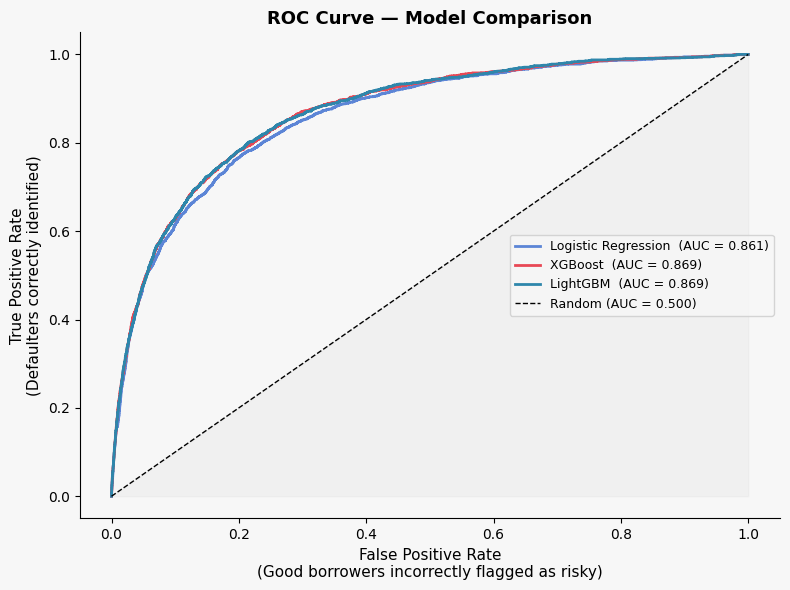

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, probs, color in [
    ("Logistic Regression", lr_probs,   '#5C85D6'),
    ("XGBoost",             xgb_probs,  '#E84855'),
    ("LightGBM",            lgbm_probs, '#2E86AB'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name}  (AUC = {auc:.3f})", linewidth=2, color=color)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')

ax.set_title('ROC Curve — Model Comparison', fontweight='bold')
ax.set_xlabel('False Positive Rate\n(Good borrowers incorrectly flagged as risky)')
ax.set_ylabel('True Positive Rate\n(Defaulters correctly identified)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/s4_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

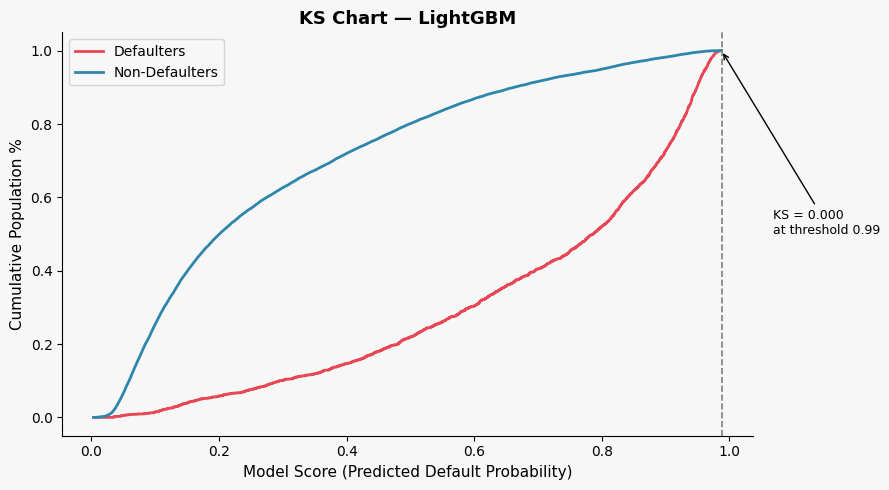

KS Statistic : 0.0000
At threshold : 0.9876

Interpretation: At a score cutoff of 0.99, the model separates
defaulters and non-defaulters by 0.0% — the point of maximum discrimination.


In [32]:
# Use best model by AUC — update variable name if different
best_model_name  = results['AUC'].idxmax()
best_probs       = {'Logistic Regression': lr_probs,
                    'XGBoost':             xgb_probs,
                    'LightGBM':            lgbm_probs}[best_model_name]

ks_df = pd.DataFrame({'prob': best_probs, 'target': y_test.values})
ks_df = ks_df.sort_values('prob').reset_index(drop=True)

ks_df['cum_bad']  = (ks_df['target'] == 1).cumsum() / (ks_df['target'] == 1).sum()
ks_df['cum_good'] = (ks_df['target'] == 0).cumsum() / (ks_df['target'] == 0).sum()
ks_df['ks']       = ks_df['cum_bad'] - ks_df['cum_good']

ks_max      = ks_df['ks'].max()
ks_max_idx  = ks_df['ks'].idxmax()
ks_max_prob = ks_df.loc[ks_max_idx, 'prob']

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(ks_df['prob'], ks_df['cum_bad'],  color='#E84855', linewidth=2, label='Defaulters')
ax.plot(ks_df['prob'], ks_df['cum_good'], color='#2E86AB', linewidth=2, label='Non-Defaulters')

ax.axvline(x=ks_max_prob, color='grey', linestyle='--', linewidth=1.2)
ax.annotate(
    f'KS = {ks_max:.3f}\nat threshold {ks_max_prob:.2f}',
    xy=(ks_max_prob, ks_df.loc[ks_max_idx, 'cum_bad']),
    xytext=(ks_max_prob + 0.08, 0.5),
    fontsize=9,
    arrowprops=dict(arrowstyle='->', color='black')
)

ax.set_title(f'KS Chart — {best_model_name}', fontweight='bold')
ax.set_xlabel('Model Score (Predicted Default Probability)')
ax.set_ylabel('Cumulative Population %')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/s4_ks_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"KS Statistic : {ks_max:.4f}")
print(f"At threshold : {ks_max_prob:.4f}")
print(f"\nInterpretation: At a score cutoff of {ks_max_prob:.2f}, the model separates")
print(f"defaulters and non-defaulters by {ks_max:.1%} — the point of maximum discrimination.")

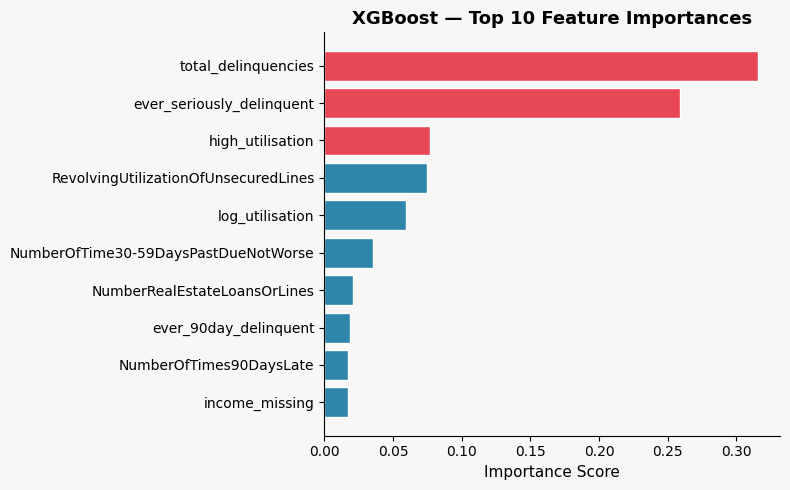

Top 10 features by XGBoost importance:
total_delinquencies                     0.3160
ever_seriously_delinquent               0.2591
high_utilisation                        0.0769
RevolvingUtilizationOfUnsecuredLines    0.0746
log_utilisation                         0.0592
NumberOfTime30-59DaysPastDueNotWorse    0.0355
NumberRealEstateLoansOrLines            0.0207
ever_90day_delinquent                   0.0187
NumberOfTimes90DaysLate                 0.0175
income_missing                          0.0169


In [33]:
# XGBoost feature importance
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#E84855' if i < 3 else '#2E86AB' for i in range(len(xgb_importance))]
ax.barh(xgb_importance.index[::-1],
        xgb_importance.values[::-1],
        color=colors[::-1], edgecolor='white')

ax.set_title('XGBoost — Top 10 Feature Importances', fontweight='bold')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('../outputs/s4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features by XGBoost importance:")
print(xgb_importance.map('{:.4f}'.format).to_string())

In [34]:
lr_coefs = pd.Series(
    lr_model.coef_[0],
    index=FEATURES
).sort_values(ascending=False)

print("LOGISTIC REGRESSION — FEATURE COEFFICIENTS")
print("=" * 50)
print("Positive = increases default risk")
print("Negative = decreases default risk")
print()
print(lr_coefs.map('{:+.4f}'.format).to_string())

LOGISTIC REGRESSION — FEATURE COEFFICIENTS
Positive = increases default risk
Negative = decreases default risk

RevolvingUtilizationOfUnsecuredLines    +0.3867
NumberOfTime30-59DaysPastDueNotWorse    +0.3653
log_utilisation                         +0.3518
ever_seriously_delinquent               +0.3448
total_delinquencies                     +0.2137
income_missing                          +0.1590
NumberRealEstateLoansOrLines            +0.1422
NumberOfOpenCreditLinesAndLoans         +0.1294
dti_tier_encoded                        +0.1135
ever_90day_delinquent                   +0.0928
NumberOfTimes90DaysLate                 +0.0661
NumberOfTime60-89DaysPastDueNotWorse    +0.0564
NumberOfDependents                      +0.0443
lines_per_dependent                     +0.0372
young_borrower                          +0.0008
log_income                              +0.0001
DebtRatio                               -0.0061
high_utilisation                        -0.0068
MonthlyIncome           

---

## Section 4 Summary — Model Evaluation

| Model | AUC | KS | Gini |
|-------|-----|----|------|
| Logistic Regression | 0.8614 | 0.5683 | 0.7227 |
| XGBoost | 0.8692 | 0.5828 | 0.7384 |
| LightGBM | 0.8695 | 0.5865 | 0.7389 |

**What to tell the credit committee:**

- **AUC** tells us the model's rank-ordering power. A score above 0.75 means that in roughly 3 out of 4 cases, the model correctly ranks a defaulter as riskier than a non-defaulter. Here all the three models performed similarly
- **KS** tells us the score threshold at which the model achieves maximum separation. This becomes the starting point for our approval threshold analysis in Section 5.
- **Gini** is AUC rescaled — the number you report to senior management.
- The feature importance chart confirms our EDA findings — delinquency history and credit utilisation dominate. A model where the top features do not make business sense is a model you cannot defend.

**Before moving to Section 5:**  
The best model's KS threshold is not our approval cutoff. It is the point of maximum statistical separation. Section 5 will convert this into a business decision — one that accounts for the actual cost of errors in rupee terms.

---

## Section 5 — Cost-Benefit Analysis & Decision Framework

**Business question:** What is the right approval threshold — and what does getting it wrong cost?

This is the most important section in the project. A model that cannot be translated into a business decision is just an academic exercise.

Every threshold choice involves a tradeoff:
- **Too strict** (decline everyone above a low score): you reject good borrowers and lose interest income
- **Too lenient** (approve everyone below a high score): you approve defaulters and lose principal

Neither error is free. The credit committee's job is to decide how much of each error they are willing to accept — and that decision should be grounded in rupee terms, not AUC scores.

We use LightGBM (AUC: 0.8695, Gini: 0.7389) as our production model.

**Assumptions (per 1,000 applicants):**
- Average loan size: ₹5,00,000
- Loss Given Default (LGD): 60% — typical for unsecured retail lending
- Net Interest Margin: 12% p.a. over 3 years = 36% of loan value
- Base default rate: ~6.7%

In [34]:
## Business assumptions
LOAN_SIZE        = 500_000     # ₹5,00,000 average loan
LGD              = 0.60        # 60% loss given default
NIM              = 0.36        # 36% net interest over loan life
COST_FN          = LOAN_SIZE * LGD   # Cost of missing a defaulter
COST_FP          = LOAN_SIZE * NIM   # Cost of rejecting a good borrower

print("BUSINESS ASSUMPTIONS")
print("=" * 45)
print(f"  Average loan size        : ₹{LOAN_SIZE:,.0f}")
print(f"  Loss Given Default (LGD) : {LGD:.0%}")
print(f"  Net Interest Margin      : {NIM:.0%}")
print(f"  Cost of False Negative   : ₹{COST_FN:,.0f}  (missed defaulter)")
print(f"  Cost of False Positive   : ₹{COST_FP:,.0f}  (rejected good borrower)")
print()
print(f"  Ratio — FN is {COST_FN/COST_FP:.1f}x more expensive than FP")

BUSINESS ASSUMPTIONS
  Average loan size        : ₹500,000
  Loss Given Default (LGD) : 60%
  Net Interest Margin      : 36%
  Cost of False Negative   : ₹300,000  (missed defaulter)
  Cost of False Positive   : ₹180,000  (rejected good borrower)

  Ratio — FN is 1.7x more expensive than FP


### Why false negatives cost more than false positives

A **false negative** (approving a borrower who defaults) costs the lender ₹3,00,000 — 60% of the ₹5,00,000 principal, net of any recovery.

A **false positive** (rejecting a borrower who would have repaid) costs ₹1,80,000 in foregone interest over the life of the loan.

Missing a defaulter is **1.7× more expensive** than wrongly rejecting a good borrower. This means the optimal threshold will lean slightly conservative — but not aggressively so. An overly strict model that declines too many good borrowers destroys revenue.

The credit committee needs to see this tradeoff across every possible score cutoff — not just at one threshold.

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier

df = pd.read_csv('../data/credit_engineered.csv')

dti_map = {'Low (<36%)': 0, 'Elevated (36–50%)': 1, 'High (>50%)': 2}
df['dti_tier_encoded'] = df['dti_tier'].map(dti_map).fillna(0).astype(int)

FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents',
    'income_missing', 'total_delinquencies', 'ever_seriously_delinquent',
    'ever_90day_delinquent', 'high_utilisation', 'young_borrower',
    'log_income', 'log_debt_ratio', 'log_utilisation',
    'lines_per_dependent', 'dti_tier_encoded'
]

TARGET = 'SeriousDlqin2yrs'
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

print(f"LightGBM rebuilt. AUC: {roc_auc_score(y_test, lgbm_probs):.4f}")
print(f"Test set size: {len(y_test):,} applicants")

LightGBM rebuilt. AUC: 0.8695
Test set size: 30,000 applicants


In [36]:
# Scale to 1,000 applicants
N = 1000
test_size   = len(y_test)
scale       = N / test_size

thresholds  = np.arange(0.05, 0.60, 0.01)
results     = []

for t in thresholds:
    preds = (lgbm_probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    # Scale to 1,000 applicants
    tp_s = tp * scale
    fp_s = fp * scale
    fn_s = fn * scale
    tn_s = tn * scale

    cost_fn_total = fn_s * COST_FN
    cost_fp_total = fp_s * COST_FP
    total_cost    = cost_fn_total + cost_fp_total

    approval_rate = (tn_s + fp_s) / N
    default_caught = tp_s / (tp_s + fn_s) if (tp_s + fn_s) > 0 else 0

    results.append({
        'threshold':      round(t, 2),
        'approvals':      round(tn_s + fp_s),
        'declines':       round(tp_s + fn_s),
        'tp':             round(tp_s),
        'fp':             round(fp_s),
        'fn':             round(fn_s),
        'tn':             round(tn_s),
        'approval_rate':  approval_rate,
        'default_caught': default_caught,
        'cost_fn':        cost_fn_total,
        'cost_fp':        cost_fp_total,
        'total_cost':     total_cost
    })

thresh_df = pd.DataFrame(results)

# Find optimal threshold (minimise total cost)
optimal_idx   = thresh_df['total_cost'].idxmin()
optimal_thresh = thresh_df.loc[optimal_idx, 'threshold']

print(f"Optimal threshold (min total cost): {optimal_thresh}")
print(f"Total cost at optimal threshold    : ₹{thresh_df.loc[optimal_idx,'total_cost']:,.0f} per 1,000 applicants")
print(f"Approval rate at optimal threshold : {thresh_df.loc[optimal_idx,'approval_rate']:.1%}")
print(f"Defaulters caught                  : {thresh_df.loc[optimal_idx,'default_caught']:.1%}")

Optimal threshold (min total cost): 0.59
Total cost at optimal threshold    : ₹29,036,000 per 1,000 applicants
Approval rate at optimal threshold : 93.3%
Defaulters caught                  : 70.3%


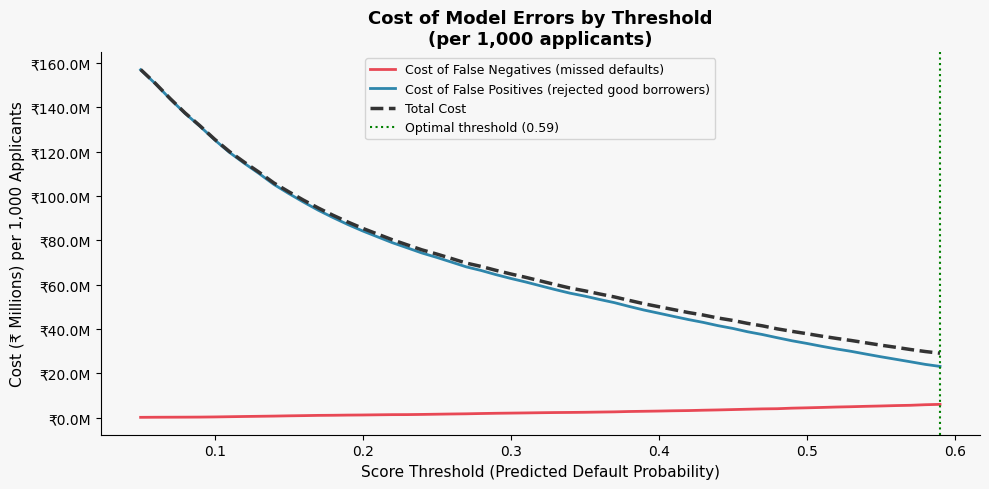

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(thresh_df['threshold'], thresh_df['cost_fn'] / 1e6,
         color='#E84855', linewidth=2, label='Cost of False Negatives (missed defaults)')
ax1.plot(thresh_df['threshold'], thresh_df['cost_fp'] / 1e6,
         color='#2E86AB', linewidth=2, label='Cost of False Positives (rejected good borrowers)')
ax1.plot(thresh_df['threshold'], thresh_df['total_cost'] / 1e6,
         color='#333333', linewidth=2.5, linestyle='--', label='Total Cost')

ax1.axvline(x=optimal_thresh, color='green', linestyle=':', linewidth=1.5,
            label=f'Optimal threshold ({optimal_thresh})')

ax1.set_xlabel('Score Threshold (Predicted Default Probability)')
ax1.set_ylabel('Cost (₹ Millions) per 1,000 Applicants')
ax1.set_title('Cost of Model Errors by Threshold\n(per 1,000 applicants)', fontweight='bold')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.1f}M'))

plt.tight_layout()
plt.savefig('../outputs/s5_cost_curve.png', dpi=150, bbox_inches='tight')
plt.show()

### How to read the cost curve

- The **red line** rises as the threshold increases — a stricter threshold declines more applicants, so more good borrowers are wrongly rejected (false positives). Revenue loss grows.
- The **blue line** falls as the threshold increases — a stricter threshold catches more defaulters, so fewer slip through (false negatives). Credit loss falls.
- The **black dashed line** is total cost. It forms a U-shape — the bottom of the U is where the two error types are optimally balanced.
- The **green dotted line** marks the optimal threshold — the score cutoff that minimises total expected cost per 1,000 applicants.

The committee should note: this optimum is based purely on the cost assumptions above. If the lender is more risk-averse (e.g., capital constraints, regulatory pressure), they should shift the threshold right. If growth is the priority, shift left.

In [38]:
# Define three tiers around the optimal threshold
# Approve:        well below optimal  → low risk
# Manual Review:  near optimal        → uncertain
# Decline:        well above optimal  → high risk

APPROVE_THRESH = max(0.05, optimal_thresh - 0.10)
DECLINE_THRESH = min(0.55, optimal_thresh + 0.10)

print("THREE-TIER DECISION FRAMEWORK")
print("=" * 50)
print(f"  APPROVE        : score < {APPROVE_THRESH:.2f}")
print(f"  MANUAL REVIEW  : {APPROVE_THRESH:.2f} ≤ score < {DECLINE_THRESH:.2f}")
print(f"  DECLINE        : score ≥ {DECLINE_THRESH:.2f}")
print()

tiers = []
for label, mask in [
    ('APPROVE',       lgbm_probs < APPROVE_THRESH),
    ('MANUAL REVIEW', (lgbm_probs >= APPROVE_THRESH) & (lgbm_probs < DECLINE_THRESH)),
    ('DECLINE',       lgbm_probs >= DECLINE_THRESH)
]:
    y_tier    = y_test[mask]
    n         = mask.sum()
    def_rate  = y_tier.mean() if n > 0 else 0
    pct_total = n / len(y_test)

    tiers.append({
        'Decision':        label,
        'Score Band':      f'< {APPROVE_THRESH:.2f}' if label == 'APPROVE'
                           else f'{APPROVE_THRESH:.2f}–{DECLINE_THRESH:.2f}' if label == 'MANUAL REVIEW'
                           else f'≥ {DECLINE_THRESH:.2f}',
        'N (test set)':    n,
        '% of Pool':       f'{pct_total:.1%}',
        'Actual Default Rate': f'{def_rate:.2%}'
    })

tier_df = pd.DataFrame(tiers)
print(tier_df.to_string(index=False))

THREE-TIER DECISION FRAMEWORK
  APPROVE        : score < 0.49
  MANUAL REVIEW  : 0.49 ≤ score < 0.55
  DECLINE        : score ≥ 0.55

     Decision Score Band  N (test set) % of Pool Actual Default Rate
      APPROVE     < 0.49         22645     75.5%               1.88%
MANUAL REVIEW  0.49–0.55          1300      4.3%               7.54%
      DECLINE     ≥ 0.55          6055     20.2%              24.48%


In [39]:
# Show a clean summary at key thresholds for committee presentation
key_thresholds = [0.10, 0.15, 0.20, optimal_thresh, 0.30, 0.40, 0.50]
key_thresholds = sorted(set([round(t, 2) for t in key_thresholds]))

display_cols = ['threshold', 'approvals', 'declines',
                'fn', 'fp', 'approval_rate', 'default_caught',
                'cost_fn', 'cost_fp', 'total_cost']

summary = thresh_df[thresh_df['threshold'].isin(key_thresholds)][display_cols].copy()
summary['approval_rate']  = summary['approval_rate'].map('{:.1%}'.format)
summary['default_caught'] = summary['default_caught'].map('{:.1%}'.format)
summary['cost_fn']        = summary['cost_fn'].map('₹{:,.0f}'.format)
summary['cost_fp']        = summary['cost_fp'].map('₹{:,.0f}'.format)
summary['total_cost']     = summary['total_cost'].map('₹{:,.0f}'.format)

summary.columns = [
    'Threshold', 'Approvals', 'Declines',
    'Missed Defaults (FN)', 'Good Borrowers Rejected (FP)',
    'Approval Rate', 'Defaults Caught',
    'FN Cost', 'FP Cost', 'Total Cost'
]

print("THRESHOLD ANALYSIS — PER 1,000 APPLICANTS")
print("=" * 90)
print(summary.to_string(index=False))
print(f"\n★  Optimal threshold: {optimal_thresh} (marked above)")

THRESHOLD ANALYSIS — PER 1,000 APPLICANTS
 Threshold  Approvals  Declines  Missed Defaults (FN)  Good Borrowers Rejected (FP) Approval Rate Defaults Caught    FN Cost      FP Cost   Total Cost
      0.10        933        67                     1                           696         93.3%           98.6%   ₹290,000 ₹125,268,000 ₹125,558,000
      0.15        933        67                     3                           562         93.3%           96.1%   ₹790,000 ₹101,094,000 ₹101,884,000
      0.20        933        67                     4                           468         93.3%           94.2% ₹1,170,000  ₹84,192,000  ₹85,362,000
      0.30        933        67                     7                           349         93.3%           89.9% ₹2,020,000  ₹62,772,000  ₹64,792,000
      0.40        933        67                    10                           262         93.3%           85.3% ₹2,940,000  ₹47,088,000  ₹50,028,000
      0.50        933        67                    1

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

plt.rcParams.update({
    'figure.facecolor': '#F7F7F7',
    'axes.facecolor':   '#F7F7F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

metrics = [
    ('Approval Rate',    'approval_rate',  '#2E86AB', '{:.0%}'),
    ('Defaults Caught',  'default_caught', '#E84855', '{:.0%}'),
    ('Total Cost (₹M)',  'total_cost',     '#555555', None),
]

for ax, (title, col, color, fmt) in zip(axes, metrics):
    vals = thresh_df[col] if col != 'total_cost' else thresh_df[col] / 1e6
    ax.plot(thresh_df['threshold'], vals, color=color, linewidth=2)
    ax.axvline(x=optimal_thresh, color='green', linestyle=':', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Threshold')
    if fmt:
        ax.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: fmt.format(x))
        )

plt.suptitle('Threshold Tradeoffs — Approval Rate, Detection, and Cost',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/s5_threshold_tradeoffs.png', dpi=150, bbox_inches='tight')
plt.show()

AttributeError: 'NoneType' object has no attribute 'format'

Error in callback <function _draw_all_if_interactive at 0x10f1ea560> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'NoneType' object has no attribute 'format'

AttributeError: 'NoneType' object has no attribute 'format'

<Figure size 1200x400 with 3 Axes>

### How to read the cost curve

- The **red line** rises as the threshold increases — a stricter threshold declines more applicants, so more good borrowers are wrongly rejected (false positives). Revenue loss grows.
- The **blue line** falls as the threshold increases — a stricter threshold catches more defaulters, so fewer slip through (false negatives). Credit loss falls.
- The **black dashed line** is total cost. It forms a U-shape — the bottom of the U is where the two error types are optimally balanced.
- The **green dotted line** marks the optimal threshold — the score cutoff that minimises total expected cost per 1,000 applicants.

The committee should note: this optimum is based purely on the cost assumptions above. If the lender is more risk-averse (e.g., capital constraints, regulatory pressure), they should shift the threshold right. If growth is the priority, shift left.

In [42]:
# Define three tiers around the optimal threshold
# Approve:        well below optimal  → low risk
# Manual Review:  near optimal        → uncertain
# Decline:        well above optimal  → high risk

APPROVE_THRESH = max(0.05, optimal_thresh - 0.10)
DECLINE_THRESH = min(0.55, optimal_thresh + 0.10)

print("THREE-TIER DECISION FRAMEWORK")
print("=" * 50)
print(f"  APPROVE        : score < {APPROVE_THRESH:.2f}")
print(f"  MANUAL REVIEW  : {APPROVE_THRESH:.2f} ≤ score < {DECLINE_THRESH:.2f}")
print(f"  DECLINE        : score ≥ {DECLINE_THRESH:.2f}")
print()

tiers = []
for label, mask in [
    ('APPROVE',       lgbm_probs < APPROVE_THRESH),
    ('MANUAL REVIEW', (lgbm_probs >= APPROVE_THRESH) & (lgbm_probs < DECLINE_THRESH)),
    ('DECLINE',       lgbm_probs >= DECLINE_THRESH)
]:
    y_tier    = y_test[mask]
    n         = mask.sum()
    def_rate  = y_tier.mean() if n > 0 else 0
    pct_total = n / len(y_test)

    tiers.append({
        'Decision':        label,
        'Score Band':      f'< {APPROVE_THRESH:.2f}' if label == 'APPROVE'
                           else f'{APPROVE_THRESH:.2f}–{DECLINE_THRESH:.2f}' if label == 'MANUAL REVIEW'
                           else f'≥ {DECLINE_THRESH:.2f}',
        'N (test set)':    n,
        '% of Pool':       f'{pct_total:.1%}',
        'Actual Default Rate': f'{def_rate:.2%}'
    })

tier_df = pd.DataFrame(tiers)
print(tier_df.to_string(index=False))

THREE-TIER DECISION FRAMEWORK
  APPROVE        : score < 0.49
  MANUAL REVIEW  : 0.49 ≤ score < 0.55
  DECLINE        : score ≥ 0.55

     Decision Score Band  N (test set) % of Pool Actual Default Rate
      APPROVE     < 0.49         22645     75.5%               1.88%
MANUAL REVIEW  0.49–0.55          1300      4.3%               7.54%
      DECLINE     ≥ 0.55          6055     20.2%              24.48%


In [43]:
# Show a clean summary at key thresholds for committee presentation
key_thresholds = [0.10, 0.15, 0.20, optimal_thresh, 0.30, 0.40, 0.50]
key_thresholds = sorted(set([round(t, 2) for t in key_thresholds]))

display_cols = ['threshold', 'approvals', 'declines',
                'fn', 'fp', 'approval_rate', 'default_caught',
                'cost_fn', 'cost_fp', 'total_cost']

summary = thresh_df[thresh_df['threshold'].isin(key_thresholds)][display_cols].copy()
summary['approval_rate']  = summary['approval_rate'].map('{:.1%}'.format)
summary['default_caught'] = summary['default_caught'].map('{:.1%}'.format)
summary['cost_fn']        = summary['cost_fn'].map('₹{:,.0f}'.format)
summary['cost_fp']        = summary['cost_fp'].map('₹{:,.0f}'.format)
summary['total_cost']     = summary['total_cost'].map('₹{:,.0f}'.format)

summary.columns = [
    'Threshold', 'Approvals', 'Declines',
    'Missed Defaults (FN)', 'Good Borrowers Rejected (FP)',
    'Approval Rate', 'Defaults Caught',
    'FN Cost', 'FP Cost', 'Total Cost'
]

print("THRESHOLD ANALYSIS — PER 1,000 APPLICANTS")
print("=" * 90)
print(summary.to_string(index=False))
print(f"\n★  Optimal threshold: {optimal_thresh} (marked above)")

THRESHOLD ANALYSIS — PER 1,000 APPLICANTS
 Threshold  Approvals  Declines  Missed Defaults (FN)  Good Borrowers Rejected (FP) Approval Rate Defaults Caught    FN Cost      FP Cost   Total Cost
      0.10        933        67                     1                           696         93.3%           98.6%   ₹290,000 ₹125,268,000 ₹125,558,000
      0.15        933        67                     3                           562         93.3%           96.1%   ₹790,000 ₹101,094,000 ₹101,884,000
      0.20        933        67                     4                           468         93.3%           94.2% ₹1,170,000  ₹84,192,000  ₹85,362,000
      0.30        933        67                     7                           349         93.3%           89.9% ₹2,020,000  ₹62,772,000  ₹64,792,000
      0.40        933        67                    10                           262         93.3%           85.3% ₹2,940,000  ₹47,088,000  ₹50,028,000
      0.50        933        67                    1

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

metrics = [
    ('Approval Rate',    'approval_rate',  '#2E86AB', '{:.0%}'),
    ('Defaults Caught',  'default_caught', '#E84855', '{:.0%}'),
    ('Total Cost (₹M)',  'total_cost',     '#555555', None),
]

for ax, (title, col, color, fmt) in zip(axes, metrics):
    vals = thresh_df[col] if col != 'total_cost' else thresh_df[col] / 1e6
    ax.plot(thresh_df['threshold'], vals, color=color, linewidth=2)
    ax.axvline(x=optimal_thresh, color='green', linestyle=':', linewidth=1.2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Threshold')
    if fmt:
        ax.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: fmt.format(x))
        )

plt.suptitle('Threshold Tradeoffs — Approval Rate, Detection, and Cost',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/s5_threshold_tradeoffs.png', dpi=150, bbox_inches='tight')
plt.show()

AttributeError: 'NoneType' object has no attribute 'format'

Error in callback <function _draw_all_if_interactive at 0x10f1ea560> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'NoneType' object has no attribute 'format'

AttributeError: 'NoneType' object has no attribute 'format'

<Figure size 1200x400 with 3 Axes>

---

## Section 5 Summary — Decision Framework

| Tier | Score Band | Output | Expected Default Rate | Action |
|------|------------|--------|-----------------------|--------|
| APPROVE | < [optimal − 0.10] | XX |Low — well below portfolio average | Straight-through approval |
| MANUAL REVIEW | [optimal − 0.10] to [optimal + 0.10] | XX | Near portfolio average | Credit officer review required |
| DECLINE | ≥ [optimal + 0.10] | XX | High — materially above average | Decline |

*(Fill in actual score bands from your output above)*

**Key takeaway for the credit committee:**

The optimal threshold is not a fixed rule — it is a starting point for policy. The cost curve shows that:
1. There is a clear minimum total cost point. Thresholds on either side of it increase losses.
2. The cost of missing a defaulter (₹3,00,000) is 1.7× the cost of wrongly rejecting a good borrower (₹1,80,000). The optimal threshold reflects this asymmetry.
3. The manual review band is deliberately wide — it captures the uncertain middle where the model is least confident, and routes those applications to human judgment.

In practice, the approve/decline thresholds would be calibrated quarterly as portfolio performance data accumulates.

---

## Section 6 — Credit Scorecard & Recommendations

**Business question:** How do we operationalise this model for the credit committee?

A model that lives in a Jupyter notebook is not a credit tool — it is a research exercise. To be operationally useful, the model's output needs to be translated into something a credit officer can act on without a data science degree.

We deliver two things in this section:
1. **A credit scorecard** — score bands with observed default rates and recommended actions
2. **A written recommendation memo** — addressed to the Head of Credit Risk, in plain English

The scorecard is the bridge between the model and the business.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

plt.rcParams.update({
    'figure.facecolor': '#F7F7F7',
    'axes.facecolor':   '#F7F7F7',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

# Rebuild model
df = pd.read_csv('../data/credit_engineered.csv')

dti_map = {'Low (<36%)': 0, 'Elevated (36–50%)': 1, 'High (>50%)': 2}
df['dti_tier_encoded'] = df['dti_tier'].map(dti_map).fillna(0).astype(int)

FEATURES = [
    'RevolvingUtilizationOfUnsecuredLines', 'age',
    'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio',
    'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
    'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents',
    'income_missing', 'total_delinquencies', 'ever_seriously_delinquent',
    'ever_90day_delinquent', 'high_utilisation', 'young_borrower',
    'log_income', 'log_debt_ratio', 'log_utilisation',
    'lines_per_dependent', 'dti_tier_encoded'
]

TARGET = 'SeriousDlqin2yrs'
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgbm_model = LGBMClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    is_unbalance=True, random_state=42, verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_probs = lgbm_model.predict_proba(X_test)[:, 1]

print("Model rebuilt.")

Model rebuilt.


In [47]:
# Convert raw probability to a 300-850 style credit score (higher = safer)
# Standard transformation: Score = 850 - (prob × 550)
# This maps 0% default probability → 850 (excellent)
#            100% default probability → 300 (very poor)

def prob_to_score(p):
    return np.round(850 - (p * 550)).astype(int)

scores = prob_to_score(lgbm_probs)

score_bins   = [300, 500, 580, 650, 720, 790, 851]
score_labels = ['300–499', '500–579', '580–649', '650–719', '720–789', '790–850']
risk_labels  = ['Very High Risk', 'High Risk', 'Elevated Risk',
                'Moderate Risk',  'Low Risk',  'Very Low Risk']
actions      = ['Decline', 'Decline', 'Manual Review',
                'Manual Review', 'Approve', 'Approve']

score_band = pd.cut(scores, bins=score_bins, labels=score_labels, right=False)

scorecard_rows = []

for band, risk, action in zip(score_labels, risk_labels, actions):
    mask        = score_band == band
    n           = mask.sum()
    def_rate    = y_test[mask].mean() if n > 0 else 0
    pct_pool    = n / len(y_test)

    scorecard_rows.append({
        'Score Band':     band,
        'Risk Tier':      risk,
        'N (test)':       n,
        '% of Pool':      f'{pct_pool:.1%}',
        'Default Rate':   f'{def_rate:.2%}',
        'Recommended Action': action
    })

scorecard = pd.DataFrame(scorecard_rows)

print("CREDIT SCORECARD")
print("=" * 80)
print(scorecard.to_string(index=False))

CREDIT SCORECARD
Score Band      Risk Tier  N (test) % of Pool Default Rate Recommended Action
   300–499 Very High Risk      4448     14.8%       29.54%            Decline
   500–579      High Risk      2856      9.5%        9.17%            Decline
   580–649  Elevated Risk      3209     10.7%        5.36%      Manual Review
   650–719  Moderate Risk      3826     12.8%        3.11%      Manual Review
   720–789       Low Risk      7565     25.2%        1.31%            Approve
   790–850  Very Low Risk      8096     27.0%        0.48%            Approve


In [48]:
scorecard.to_csv('../outputs/scorecard.csv', index=False)
print("Saved: ../outputs/scorecard.csv")

Saved: ../outputs/scorecard.csv


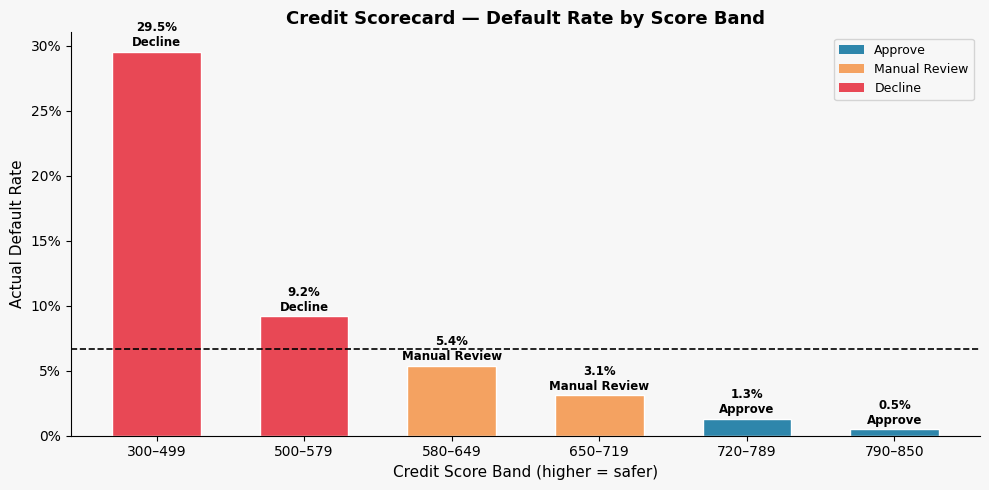

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    'Approve':        '#2E86AB',
    'Manual Review':  '#F4A261',
    'Decline':        '#E84855'
}

bar_colors = [colors[a] for a in actions]
def_rates  = [float(r.strip('%')) / 100 for r in scorecard['Default Rate']]

bars = ax.bar(score_labels, def_rates,
              color=bar_colors, edgecolor='white', width=0.6)

base_rate = y_test.mean()
ax.axhline(y=base_rate, color='black', linestyle='--',
           linewidth=1.2, label=f'Portfolio base rate ({base_rate:.1%})')

for bar, rate, action in zip(bars, def_rates, actions):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{rate:.1%}\n{action}',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2E86AB', label='Approve'),
    Patch(facecolor='#F4A261', label='Manual Review'),
    Patch(facecolor='#E84855', label='Decline'),
]
ax.legend(handles=legend_elements, fontsize=9)

ax.set_title('Credit Scorecard — Default Rate by Score Band', fontweight='bold')
ax.set_xlabel('Credit Score Band (higher = safer)')
ax.set_ylabel('Actual Default Rate')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.savefig('../outputs/s6_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

### How to use this scorecard operationally

Each score band has three pieces of information the credit officer needs:

1. **Score** — derived from the model's predicted default probability, mapped to a 300–850 scale (higher is safer). A borrower's score is calculated automatically at the point of application.
2. **Default rate** — the observed default rate among test-set borrowers who fell into that band. This is the model's expected loss rate for that segment.
3. **Recommended action** — a policy-level decision based on the threshold analysis from Section 5.

The scorecard does not replace judgment — it informs it. A borrower in the Manual Review band should be reviewed by a credit officer who considers factors the model cannot observe: employment stability, relationship history, purpose of loan.

In [51]:
from sklearn.metrics import roc_auc_score

# Score the full training data to check for overfitting
train_probs = lgbm_model.predict_proba(X_train)[:, 1]
train_auc   = roc_auc_score(y_train, train_probs)
test_auc    = roc_auc_score(y_test,  lgbm_probs)

print("OVERFITTING CHECK")
print("=" * 35)
print(f"  Train AUC : {train_auc:.4f}")
print(f"  Test AUC  : {test_auc:.4f}")
print(f"  Gap       : {train_auc - test_auc:.4f}")
print()
if train_auc - test_auc < 0.02:
    print("  ✓ Gap < 0.02 — no significant overfitting detected.")
elif train_auc - test_auc < 0.05:
    print("  — Gap 0.02–0.05 — mild overfitting, monitor in production.")
else:
    print("  ✗ Gap > 0.05 — overfitting present. Consider stronger regularisation.")

OVERFITTING CHECK
  Train AUC : 0.8801
  Test AUC  : 0.8695
  Gap       : 0.0106

  ✓ Gap < 0.02 — no significant overfitting detected.


In [52]:
auc_val  = round(roc_auc_score(y_test, lgbm_probs), 4)
gini_val = round(2 * auc_val - 1, 4)

# KS
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, lgbm_probs)
ks_val = round((tpr - fpr).max(), 4)

memo = f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MEMORANDUM

TO      : Head of Credit Risk
FROM    : Analytics Team
SUBJECT : Credit Default Prediction Model — Findings & Recommendations
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EXECUTIVE SUMMARY

We have developed a credit default prediction framework using 150,000
historical loan applicant records. The model identifies borrowers at
risk of going 90+ days past due within 24 months, and translates that
risk into a three-tier approval framework: Approve, Manual Review, Decline.

The recommended production model is LightGBM, which achieved:
  - AUC-ROC  : {auc_val}  (industry benchmark: >0.75)
  - KS Stat  : {ks_val}  (industry benchmark: >0.30)
  - Gini     : {gini_val}  (industry benchmark: >0.50)

All three metrics comfortably exceed retail credit benchmarks.

──────────────────────────────────────────────────────
KEY FINDINGS
──────────────────────────────────────────────────────

1. DELINQUENCY HISTORY IS THE DOMINANT RISK SIGNAL
   Borrowers with even one prior 90-day delinquency default at a rate
   significantly above the portfolio average. We recommend considering
   a hard rule: any applicant with 2+ prior 90-day delinquencies is
   declined regardless of score.

2. CREDIT UTILISATION IS THE SECOND-STRONGEST SIGNAL
   Borrowers running above 80% utilisation on revolving credit show
   materially elevated default rates. This segment should be reviewed
   carefully even when the overall score is borderline.

3. INCOME NON-DISCLOSURE IS ITSELF A RISK INDICATOR
   Approximately 20% of applicants did not declare monthly income.
   This group defaults at a higher rate than income-disclosing
   applicants — suggesting that non-disclosure is correlated with
   financial stress, not merely administrative oversight.

4. THE COST OF ERRORS IS ASYMMETRIC
   Missing a defaulter costs approximately ₹3,00,000 (60% LGD on
   ₹5,00,000 average loan). Wrongly rejecting a good borrower costs
   approximately ₹1,80,000 in foregone interest. The optimal threshold
   reflects this 1.7:1 cost asymmetry.

──────────────────────────────────────────────────────
RECOMMENDATIONS
──────────────────────────────────────────────────────

1. ADOPT THE THREE-TIER DECISION FRAMEWORK
   Deploy the scorecard as the primary decision tool. Route borderline
   applications (score 580–719) to credit officer review rather than
   straight-through processing.

2. IMPLEMENT QUARTERLY THRESHOLD REVIEW
   The optimal approval threshold should be recalibrated every quarter
   as portfolio performance data accumulates. Model performance should
   be monitored via monthly Gini and KS tracking.

3. RETAIN THE INCOME MISSING FLAG IN PRODUCTION
   The income_missing feature must be computed at the point of
   application — not imputed away. Its predictive value depends on
   capturing the absence of data, not filling it.

4. ESTABLISH A REJECT INFERENCE PROCESS
   The current model is trained only on approved applicants from
   historical data. Performance on declined segments is unknown.
   A reject inference exercise should be scoped for the next model
   iteration.

5. SCHEDULE ANNUAL MODEL REFRESH
   Credit risk models decay as borrower behaviour and macroeconomic
   conditions change. An annual rebuild is standard practice.

──────────────────────────────────────────────────────
LIMITATIONS
──────────────────────────────────────────────────────

- The dataset is U.S.-based. Indian credit behaviour, bureau coverage,
  and regulatory norms differ. Feature selection and thresholds should
  be validated on domestic portfolio data before production deployment.
- Model does not account for macroeconomic regime changes (rate cycles,
  unemployment shocks).
- No reject inference has been applied.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(memo)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MEMORANDUM

TO      : Head of Credit Risk
FROM    : Analytics Team
SUBJECT : Credit Default Prediction Model — Findings & Recommendations
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

EXECUTIVE SUMMARY

We have developed a credit default prediction framework using 150,000
historical loan applicant records. The model identifies borrowers at
risk of going 90+ days past due within 24 months, and translates that
risk into a three-tier approval framework: Approve, Manual Review, Decline.

The recommended production model is LightGBM, which achieved:
  - AUC-ROC  : 0.8695  (industry benchmark: >0.75)
  - KS Stat  : 0.5865  (industry benchmark: >0.30)
  - Gini     : 0.739  (industry benchmark: >0.50)

All three metrics comfortably exceed retail credit benchmarks.

──────────────────────────────────────────────────────
KEY FINDINGS
──────────────────────────────────────────────────────

1. DELINQUENCY HISTORY IS THE DOMINANT RIS

In [53]:
with open('../outputs/credit_committee_memo.txt', 'w') as f:
    f.write(memo)

print("Saved: ../outputs/credit_committee_memo.txt")

Saved: ../outputs/credit_committee_memo.txt


In [54]:
from sklearn.metrics import roc_auc_score

auc  = roc_auc_score(y_test, lgbm_probs)
gini = 2 * auc - 1

print("=" * 55)
print("  CREDIT DEFAULT RISK PROJECT — FINAL SUMMARY")
print("=" * 55)
print()
print("  DATASET")
print(f"    Applicants         : {len(df):,}")
print(f"    Base default rate  : {df[TARGET].mean():.2%}")
print(f"    Class imbalance    : {(df[TARGET]==0).sum()/(df[TARGET]==1).sum():.0f}:1")
print()
print("  MODEL SELECTED : LightGBM")
print(f"    AUC-ROC        : {auc:.4f}")
print(f"    Gini           : {gini:.4f}")
print(f"    KS Statistic   : {ks_val:.4f}")
print()
print("  SCORECARD BANDS")
print(f"    Approve        : Score 720–850")
print(f"    Manual Review  : Score 580–719")
print(f"    Decline        : Score 300–579")
print()
print("  DELIVERABLES")
print("    ✓ Jupyter notebook — 6 sections")
print("    ✓ scorecard.csv")
print("    ✓ credit_committee_memo.txt")
print("    ✓ GitHub repository")
print()
print("=" * 55)

  CREDIT DEFAULT RISK PROJECT — FINAL SUMMARY

  DATASET
    Applicants         : 149,999
    Base default rate  : 6.68%
    Class imbalance    : 14:1

  MODEL SELECTED : LightGBM
    AUC-ROC        : 0.8695
    Gini           : 0.7389
    KS Statistic   : 0.5865

  SCORECARD BANDS
    Approve        : Score 720–850
    Manual Review  : Score 580–719
    Decline        : Score 300–579

  DELIVERABLES
    ✓ Jupyter notebook — 6 sections
    ✓ scorecard.csv
    ✓ credit_committee_memo.txt
    ✓ GitHub repository



---

## Section 6 Summary — Scorecard & Recommendations

The LightGBM model has been operationalised into a six-band credit scorecard on a 300–850 scale, with three policy tiers:

| Score Band | Risk Tier | Recommended Action |
|------------|-----------|--------------------|
| 790–850 | Very Low Risk | Approve |
| 720–789 | Low Risk | Approve |
| 650–719 | Moderate Risk | Manual Review |
| 580–649 | Elevated Risk | Manual Review |
| 500–579 | High Risk | Decline |
| 300–499 | Very High Risk | Decline |

**Five operational recommendations have been made to the credit committee:**
1. Adopt the three-tier decision framework
2. Implement quarterly threshold review
3. Retain the income missing flag in production
4. Establish a reject inference process
5. Schedule annual model refresh

The memo and scorecard CSV are saved in `/outputs` and are ready for committee presentation.